# Task 2: Linear Regression Model on the Iris Dataset

**Objective:** Build a simple Linear Regression model on the Iris dataset that predicts a flower's **Petal Width** from its **Petal Length**, following standard industry best practice

## 1. Import Libraries

In [1]:
# Import libraries for data handling, visualization, and modeling
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
%matplotlib inline

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load the Dataset

We are using the classic **Iris dataset** (150 samples, 3 species). For this regression task,
we will use two of its numeric features:
- **Petal Length** (cm), the independent variable (X)
- **Petal Width** (cm), the dependent variable / target (y)

These two features are known to be strongly correlated, which makes them a great pair for demonstrating simple linear regression.

In [2]:
# Load the dataset
df = pd.read_csv("data/iris.csv")
df.head(10)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


## 3. Basic Data Exploration (Mini-EDA)

In [3]:
print("Shape of dataset:", df.shape)
df.info()

Shape of dataset: (150, 5)
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [4]:
# Check for missing values
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [5]:
# Statistical summary of the numeric columns
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## 4. Visualize the Relationship

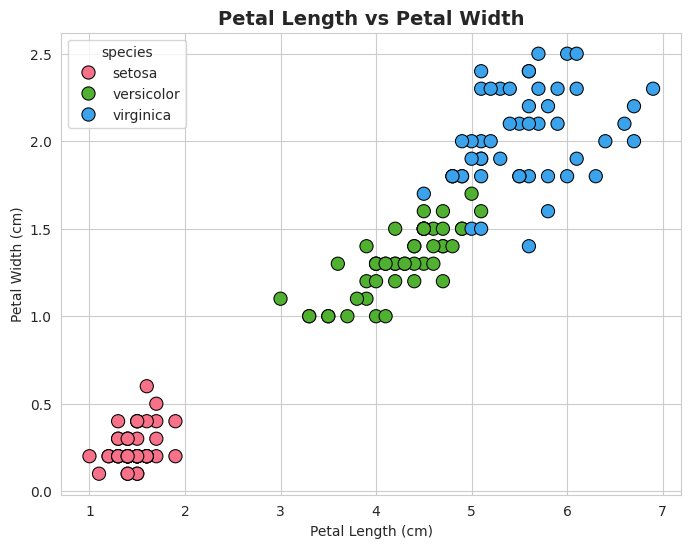

In [6]:
# Scatter plot of Petal Length vs Petal Width, colored by species just to see the pattern
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='petal_length', y='petal_width', hue='species',
                 palette='husl', s=90, edgecolor='black')
plt.title('Petal Length vs Petal Width', fontsize=14, fontweight='bold')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.savefig("screenshots/01_scatter_petal_length_vs_width.png", dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# Correlation between the two variables
correlation = df['petal_length'].corr(df['petal_width'])
print(f"Correlation between Petal Length and Petal Width: {correlation:.3f}")

Correlation between Petal Length and Petal Width: 0.963


### Observation
The scatter plot shows a clear **positive linear relationship** as petal length increases, petal width tends to increase too. The very high correlation (~0.96) confirms that a **linear regression model** is a great fit for this data.

## 5. Prepare Data for Modeling

In [8]:
# Feature (X) and target (y)
X = df[['petal_length']]   # double brackets -> keeps it as a DataFrame (2D), required by sklearn
y = df['petal_width']

# Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


## 6. Train the Linear Regression Model

In [9]:
# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")
print(f"Intercept (b0): {model.intercept_:.4f}")
print(f"Coefficient / Slope (b1): {model.coef_[0]:.4f}")

Model trained successfully!
Intercept (b0): -0.3567
Coefficient / Slope (b1): 0.4132


### Interpreting the Model
Our fitted line is roughly:

**Petal Width = Intercept + (Slope × Petal Length)**

This means for every extra centimeter of petal length, the model predicts petal width
increases by approximately the slope value shown above.

## 7. Make Predictions on Test Data

In [10]:
y_pred = model.predict(X_test)

# Compare actual vs predicted values
results_df = pd.DataFrame({'Actual Petal Width': y_test.values, 'Predicted Petal Width': np.round(y_pred, 3)})
results_df

,Actual Petal Width,Predicted Petal Width
0,1.2,1.586
1,0.3,0.346
2,2.3,2.495
3,1.5,1.503
4,1.4,1.627
5,0.4,0.263
6,1.3,1.131
7,2.3,1.751
8,1.5,1.503
9,1.2,1.255


## 8. Evaluate the Model

In [11]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Metrics")
print("-" * 35)
print(f"Mean Absolute Error (MAE):  {mae:.4f}")
print(f"Mean Squared Error (MSE):   {mse:.4f}")
print(f"Root Mean Squared Error:    {rmse:.4f}")
print(f"R-squared (R2 Score):       {r2:.4f}")

Model Evaluation Metrics
-----------------------------------
Mean Absolute Error (MAE):  0.1682
Mean Squared Error (MSE):   0.0456
Root Mean Squared Error:    0.2136
R-squared (R2 Score):       0.9283


### What do these metrics mean?
- **MAE** : on average, our predictions are off by this many cm.
- **RMSE** : similar to MAE but penalizes larger errors more.
- **R² Score** : how much of the variation in petal width is explained by petal length
  (closer to 1.0 = better fit). Our score close to 1 shows the model fits very well.

## 9. Visualize the Regression Line

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


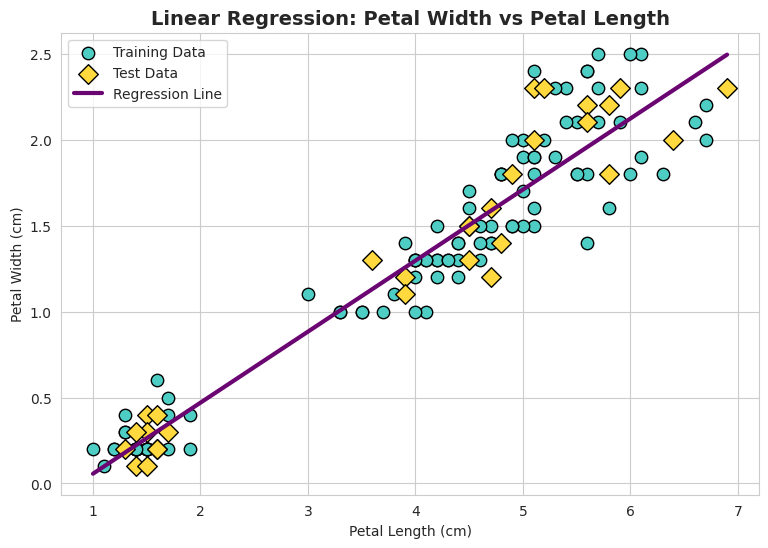

In [12]:
# Plot the regression line against the actual training and test data
plt.figure(figsize=(9, 6))

plt.scatter(X_train, y_train, color='#4ECDC4', s=80, edgecolor='black', label='Training Data')
plt.scatter(X_test, y_test, color='#FFD93D', s=100, edgecolor='black', marker='D', label='Test Data')

# Regression line across the full range of X
x_range = np.linspace(df['petal_length'].min(), df['petal_length'].max(), 100).reshape(-1, 1)
plt.plot(x_range, model.predict(x_range), color='#6A0572', linewidth=3, label='Regression Line')

plt.title('Linear Regression: Petal Width vs Petal Length', fontsize=14, fontweight='bold')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.legend()
plt.savefig("screenshots/02_regression_line_fit.png", dpi=150, bbox_inches='tight')
plt.show()

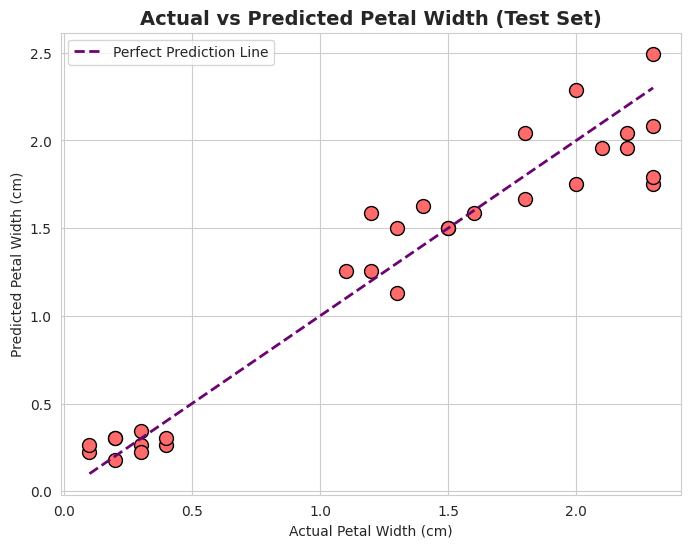

In [13]:
# Actual vs Predicted comparison plot for the test set
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='#FF6B6B', s=100, edgecolor='black')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='#6A0572', linestyle='--', linewidth=2, label='Perfect Prediction Line')
plt.title('Actual vs Predicted Petal Width (Test Set)', fontsize=14, fontweight='bold')
plt.xlabel('Actual Petal Width (cm)')
plt.ylabel('Predicted Petal Width (cm)')
plt.legend()
plt.savefig("screenshots/03_actual_vs_predicted.png", dpi=150, bbox_inches='tight')
plt.show()

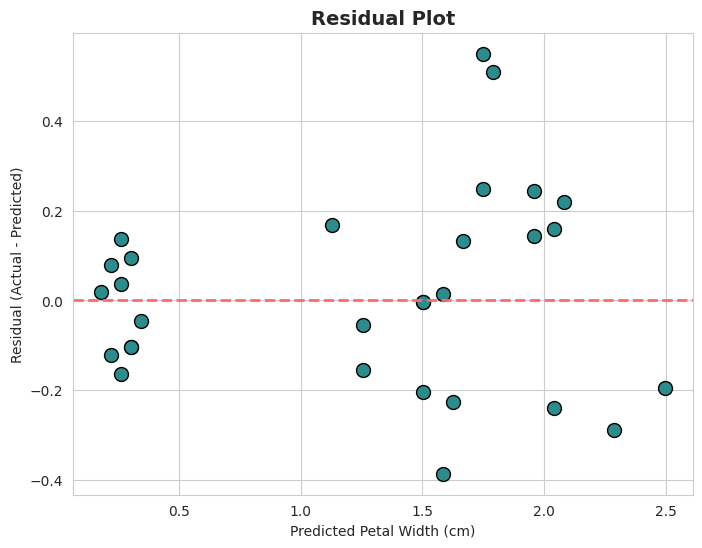

In [14]:
# Residual plot - shows the errors (residuals) for each prediction
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, color='#2E8B8B', s=100, edgecolor='black')
plt.axhline(y=0, color='#FF6B6B', linestyle='--', linewidth=2)
plt.title('Residual Plot', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Petal Width (cm)')
plt.ylabel('Residual (Actual - Predicted)')
plt.savefig("screenshots/04_residual_plot.png", dpi=150, bbox_inches='tight')
plt.show()

## 10. Predict Petal Width for a New Flower

In [15]:
# Example: Predict petal width for a flower with petal length = 4.5 cm
new_petal_length = pd.DataFrame({'petal_length': [4.5]})
predicted_width = model.predict(new_petal_length)
print(f"Predicted petal width for a petal length of 4.5 cm: {predicted_width[0]:.2f} cm")

Predicted petal width for a petal length of 4.5 cm: 1.50 cm
